In [ ]:
import pandas as pd
import glob
import os
import io

path = '/content/drive/MyDrive/Colab Notebooks/Sheryar/Training'

csv_files = glob.glob(os.path.join(path, "*.csv"))

data_dict = {}
target_cols = ['B1', 'B2', 'B3', 'B4']

for f in csv_files:
    df_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing: {df_name}")

    try:
        with open(f, 'r') as file:
            lines = file.readlines()

        header_line = lines[7].lstrip(';').strip()
        data_lines = [line.strip() for line in lines[9:]]

        csv_content = "\n".join([header_line] + data_lines)

        df = pd.read_csv(io.StringIO(csv_content), sep=',', skipinitialspace=True)

        available_cols = [col for col in target_cols if col in df.columns]
        data_dict[df_name] = df[available_cols]

        print(f"  Successfully loaded {df_name} with shape: {data_dict[df_name].shape}")
        if not data_dict[df_name].empty:
             display(data_dict[df_name].head(2))
    except Exception as e:
        print(f"  Error processing {f}: {e}")

print(f"\nCreated {len(data_dict)} separate DataFrames.")

Processing: urban
  Successfully loaded urban with shape: (495553, 4)


,B1,B2,B3,B4
0,298,332,261,263
1,305,343,271,272


Processing: water
  Successfully loaded water with shape: (386814, 4)


,B1,B2,B3,B4
0,235,251,186,185
1,236,250,187,177


Processing: road
  Successfully loaded road with shape: (69203, 4)


...

Processing: tesstt
  Successfully loaded tesstt with shape: (0, 4)
Processing: cpf-253
  Successfully loaded cpf-253 with shape: (133030, 4)


,B1,B2,B3,B4
0,244,262,189,243
1,244,263,188,247


Processing: sl-284
  Successfully loaded sl-284 with shape: (232509, 4)


,B1,B2,B3,B4
0,247,261,188,257
1,251,266,191,263



Created 6 separate DataFrames.


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder # For normalization and label encoding
import pandas as pd

all_dfs = []
MAX_PIXELS_PER_CLASS = 133000

print("Processing individual dataframes for pixel limit and class labeling...")
for class_name, df in data_dict.items():
    if len(df) > MAX_PIXELS_PER_CLASS:
        df_sampled = df.sample(n=MAX_PIXELS_PER_CLASS, random_state=42).copy() # Use random_state for reproducibility
        print(f"  Class '{class_name}' sampled from {len(df)} to {MAX_PIXELS_PER_CLASS} pixels.")
    else:
        df_sampled = df.copy()
        print(f"  Class '{class_name}' (size: {len(df)}) kept as is.")

    df_sampled['class'] = class_name
    all_dfs.append(df_sampled)

final_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nCombined final_df created with shape: {final_df.shape}")
print("First 5 rows of final_df with class labels (strings):")
display(final_df.head())

bands_df = final_df[['B1', 'B2', 'B3', 'B4']].copy()

B = bands_df['B1']
G = bands_df['B2']
R = bands_df['B3']
NIR = bands_df['B4']

bands_df['GNDVI'] = (NIR - G) / (NIR + G + 1e-6)

bands_df['EVI'] = 2.5 * ((NIR - R) / (NIR + 6 * R - 7.5 * B + 1 + 1e-6))

bands_df['SAVI'] = ((NIR - R) * (1 + 0.5)) / (NIR + R + 0.5 + 1e-6)

engineered_df = bands_df

print(f"\nDataFrame after feature engineering: {engineered_df.shape}")
print("First 5 rows of engineered_df before normalization:")
display(engineered_df.head())

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']

scaler = StandardScaler()


engineered_df[feature_cols] = scaler.fit_transform(engineered_df[feature_cols])

print(f"\nDataFrame after normalization: {engineered_df.shape}")
print("First 5 rows of engineered_df after normalization:")
display(engineered_df.head())


engineered_df['class'] = final_df['class']

label_encoder = LabelEncoder()
engineered_df['class'] = label_encoder.fit_transform(engineered_df['class'])

print(f"\nFinal DataFrame with engineered and normalized features and INTEGER class labels: {engineered_df.shape}")
print("First 5 rows of the final engineered DataFrame:")
display(engineered_df.head())
print(f"\nMapping of original class names to integer labels: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Processing individual dataframes for pixel limit and class labeling...
  Class 'urban' sampled from 495553 to 133000 pixels.
  Class 'water' sampled from 386814 to 133000 pixels.
  Class 'road' (size: 69203) kept as is.
  Class 'tesstt' (size: 0) kept as is.
  Class 'cpf-253' sampled from 133030 to 133000 pixels.
  Class 'sl-284' sampled from 232509 to 133000 pixels.

Combined final_df created with shape: (601203, 5)
First 5 rows of final_df with class labels (strings):


,B1,B2,B3,B4,class
0,295,328,256,250,urban
1,309,356,290,294,urban
2,272,297,231,229,urban
3,267,293,232,230,urban
4,286,323,260,261,urban



DataFrame after feature engineering: (601203, 7)
First 5 rows of engineered_df before normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,295,328,256,250,-0.134948,0.035253,-0.017769
1,309,356,290,294,-0.095385,-0.035398,0.010265
2,272,297,231,229,-0.129278,0.011792,-0.006515
3,267,293,232,230,-0.120459,0.013175,-0.006486
4,286,323,260,261,-0.106164,-0.00774,0.002876



DataFrame after normalization: (601203, 7)
First 5 rows of engineered_df after normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358



Final DataFrame with engineered and normalized features and INTEGER class labels: (601203, 8)
First 5 rows of the final engineered DataFrame:


,B1,B2,B3,B4,GNDVI,EVI,SAVI,class
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244,3
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209,3
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721,3
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507,3
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358,3



Mapping of original class names to integer labels: [('cpf-253', np.int64(0)), ('road', np.int64(1)), ('sl-284', np.int64(2)), ('urban', np.int64(3)), ('water', np.int64(4))]


Training on: cuda
Starting Grid Search for 8 combinations...

Trial 1/8: {'dim_model': 32, 'nhead': 4, 'num_layers': 2}

Trial 2/8: {'dim_model': 32, 'nhead': 4, 'num_layers': 3}

Trial 3/8: {'dim_model': 32, 'nhead': 8, 'num_layers': 2}

Trial 4/8: {'dim_model': 32, 'nhead': 8, 'num_layers': 3}

Trial 5/8: {'dim_model': 64, 'nhead': 4, 'num_layers': 2}

Trial 6/8: {'dim_model': 64, 'nhead': 4, 'num_layers': 3}

Trial 7/8: {'dim_model': 64, 'nhead': 8, 'num_layers': 2}

Trial 8/8: {'dim_model': 64, 'nhead': 8, 'num_layers': 3}


,dim_model,nhead,num_layers,train_acc,test_acc,final_train_loss,precision,recall,f1-score,kappa,all_preds,all_labels
1,32,4,3,0.899246,0.903303,0.263547,0.904643,0.903303,0.903731,0.877635,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
5,64,4,3,0.898295,0.903128,0.263657,0.905155,0.903128,0.903865,0.877521,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
4,64,4,2,0.899603,0.902729,0.259200,0.905037,0.902729,0.903367,0.876921,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
6,64,8,2,0.899485,0.902379,0.259163,0.904029,0.902379,0.902966,0.876576,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
0,32,4,2,0.900111,0.902263,0.259402,0.904102,0.902263,0.902933,0.876394,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
7,64,8,3,0.898597,0.901182,0.263093,0.902178,0.901182,0.901519,0.875017,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
2,32,8,2,0.899763,0.898446,0.259521,0.900265,0.898446,0.898670,0.871444,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
3,32,8,3,0.899252,0.898113,0.263514,0.899815,0.898113,0.898119,0.871056,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."



--- Important Things for Research Paper ---

Important Hyperparameters (Best Model):
  Number of transformer layers: 3
  Attention heads: 4
  Embedding dimension: 32
  Learning rate: 0.001
  Batch size: 128

Important Metrics (Best Model on Test Set):
  Accuracy: 0.9033
  Precision (weighted avg): 0.9046
  Recall (weighted avg): 0.9033
  F1-score (weighted avg): 0.9037
  Kappa score: 0.8776

Detailed Classification Report (Best Model on Test Set):
              precision    recall  f1-score   support

     cpf-253       0.84      0.86      0.85     26600
        road       0.89      0.84      0.86     13841
      sl-284       0.84      0.88      0.86     26600
       urban       0.95      0.95      0.95     26600
       water       0.99      0.96      0.97     26600

    accuracy                           0.90    120241
   macro avg       0.90      0.90      0.90    120241
weighted avg       0.90      0.90      0.90    120241


Confusion Matrix (Best Model on Test Set):


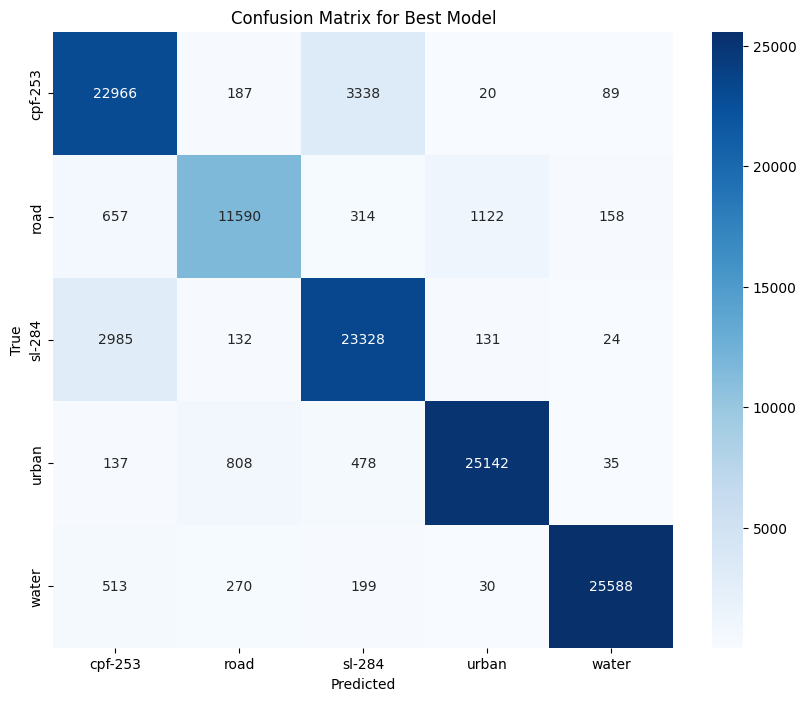


Important Tables:
Hyperparameter configuration table (results_df):


,dim_model,nhead,num_layers,train_acc,test_acc,final_train_loss,precision,recall,f1-score,kappa,all_preds,all_labels
1,32,4,3,0.899246,0.903303,0.263547,0.904643,0.903303,0.903731,0.877635,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
5,64,4,3,0.898295,0.903128,0.263657,0.905155,0.903128,0.903865,0.877521,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
4,64,4,2,0.899603,0.902729,0.259200,0.905037,0.902729,0.903367,0.876921,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
6,64,8,2,0.899485,0.902379,0.259163,0.904029,0.902379,0.902966,0.876576,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
0,32,4,2,0.900111,0.902263,0.259402,0.904102,0.902263,0.902933,0.876394,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
7,64,8,3,0.898597,0.901182,0.263093,0.902178,0.901182,0.901519,0.875017,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
2,32,8,2,0.899763,0.898446,0.259521,0.900265,0.898446,0.898670,0.871444,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."
3,32,8,3,0.899252,0.898113,0.263514,0.899815,0.898113,0.898119,0.871056,"[2, 2, 4, 3, 3, 0, 3, 2, 4, 4, 4, 2, 2, 3, 4, ...","[2, 2, 4, 3, 3, 0, 3, 0, 4, 4, 4, 2, 2, 3, 4, ..."


In [ ]:
import torch.nn as nn
import torch.optim as optim
import itertools
import pandas as pd
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

INPUT_DIM = len(feature_cols)
NUM_CLASSES = len(label_encoder.classes_)
LABEL_NAMES = label_encoder.classes_.tolist()

class TabularTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, dim_model=64, nhead=4, num_layers=2):
        super(TabularTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return self.fc(x)
FIXED_LR = 0.001
FIXED_BATCH_SIZE = 128 # Assuming this is used by your DataLoader

X = engineered_df[feature_cols].values
y = engineered_df['class'].values

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=True) # Shuffling for training data loader is generally recommended
test_loader = DataLoader(test_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=False)

param_grid = {
    'dim_model': [32, 64],
    'nhead': [4, 8],
    'num_layers': [2, 3]
}

all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

def train_and_evaluate(params, train_loader, test_loader, num_epochs=5):
    model = TabularTransformer(
        input_dim=INPUT_DIM,
        num_classes=NUM_CLASSES,
        dim_model=params['dim_model'],
        nhead=params['nhead'],
        num_layers=params['num_layers']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=FIXED_LR)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(all_labels, all_preds, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
    kappa = cohen_kappa_score(all_labels, all_preds)

    return {
        **params,
        'train_acc': correct_train / total_train,
        'test_acc': report['accuracy'],
        'final_train_loss': train_loss / len(train_loader),
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1-score': report['weighted avg']['f1-score'],
        'kappa': kappa,
        'all_preds': all_preds,
        'all_labels': all_labels
    }

print(f"Starting Grid Search for {len(all_params)} combinations...")
for i, params in enumerate(all_params):
    print(f"\nTrial {i+1}/{len(all_params)}: {params}")
    res = train_and_evaluate(params, train_loader, test_loader)
    results.append(res)

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='test_acc', ascending=False))

print("\n--- Important Things for Research Paper ---")

best_result = results_df.sort_values(by='test_acc', ascending=False).iloc[0]

print("\nImportant Hyperparameters (Best Model):")
print(f"  Number of transformer layers: {best_result['num_layers']}")
print(f"  Attention heads: {best_result['nhead']}")
print(f"  Embedding dimension: {best_result['dim_model']}")
print(f"  Learning rate: {FIXED_LR}")
print(f"  Batch size: {FIXED_BATCH_SIZE}") # Assuming batch size used by DataLoader

print("\nImportant Metrics (Best Model on Test Set):")
print(f"  Accuracy: {best_result['test_acc']:.4f}")
print(f"  Precision (weighted avg): {best_result['precision']:.4f}")
print(f"  Recall (weighted avg): {best_result['recall']:.4f}")
print(f"  F1-score (weighted avg): {best_result['f1-score']:.4f}")
print(f"  Kappa score: {best_result['kappa']:.4f}")

print("\nDetailed Classification Report (Best Model on Test Set):")
final_report = classification_report(
    best_result['all_labels'], best_result['all_preds'],
    target_names=LABEL_NAMES, zero_division=0
)
print(final_report)

print("\nConfusion Matrix (Best Model on Test Set):")
cm = confusion_matrix(best_result['all_labels'], best_result['all_preds'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Best Model')
plt.show()

print("\nImportant Tables:")
print("Hyperparameter configuration table (results_df):")
display(results_df.sort_values(by='test_acc', ascending=False))

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.metrics import classification_report

INPUT_DIM = 7
NUM_CLASSES = 5
FIXED_LR = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class TabularTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, dim_model=64, nhead=4, num_layers=2):
        super(TabularTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return self.fc(x)

def train_model_for_permutation(params, train_loader, num_epochs=5):
    model = TabularTransformer(
        input_dim=INPUT_DIM,
        num_classes=NUM_CLASSES,
        dim_model=params['dim_model'],
        nhead=params['nhead'],
        num_layers=params['num_layers']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=FIXED_LR)

    model.train()
    for epoch in range(num_epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model


best_result = results_df.sort_values(by='test_acc', ascending=False).iloc[0]
best_params = {
    'dim_model': best_result['dim_model'],
    'nhead': best_result['nhead'],
    'num_layers': best_result['num_layers']
}

best_model = train_model_for_permutation(best_params, train_loader, num_epochs=5)

best_model.eval()
all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

print("\nDetailed Classification Report (Best Model on Training Set):")
training_report = classification_report(
    all_train_labels, all_train_preds,
    target_names=LABEL_NAMES, zero_division=0
)
print(training_report)


Detailed Classification Report (Best Model on Training Set):
              precision    recall  f1-score   support

     cpf-253       0.84      0.87      0.85    106400
        road       0.87      0.86      0.86     55362
      sl-284       0.84      0.87      0.86    106400
       urban       0.97      0.92      0.94    106400
       water       0.98      0.97      0.97    106400

    accuracy                           0.90    480962
   macro avg       0.90      0.90      0.90    480962
weighted avg       0.90      0.90      0.90    480962



Best model parameters found: {'dim_model': np.int64(32), 'nhead': np.int64(4), 'num_layers': np.int64(3)}
Retraining the best model to get its weights for permutation importance calculation...
Baseline accuracy for permutation importance: 0.8973

Calculating permutation importances...
  Feature 'B1': Importance = 0.4499
  Feature 'B2': Importance = 0.3945
  Feature 'B3': Importance = 0.4336
  Feature 'B4': Importance = 0.2392
  Feature 'GNDVI': Importance = 0.5495
  Feature 'EVI': Importance = 0.2746
  Feature 'SAVI': Importance = 0.3973

--- Feature Importance Table ---


,Feature,Importance
4,GNDVI,0.549496
0,B1,0.449863
2,B3,0.433588
6,SAVI,0.397261
1,B2,0.394549
5,EVI,0.274590
3,B4,0.239211


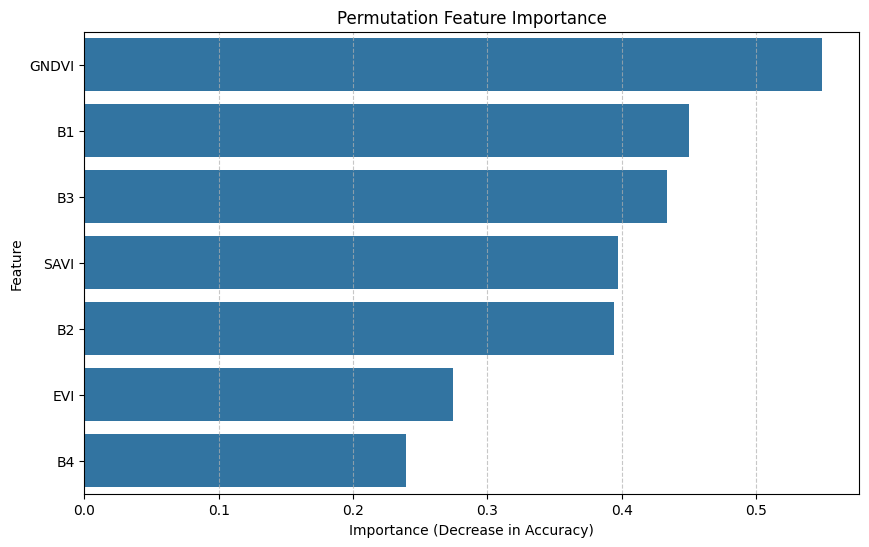

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

best_result = results_df.sort_values(by='test_acc', ascending=False).iloc[0]
best_params = {
    'dim_model': best_result['dim_model'],
    'nhead': best_result['nhead'],
    'num_layers': best_result['num_layers']
}

print(f"Best model parameters found: {best_params}")

def train_model_for_permutation(params, train_loader, num_epochs=5):
    model = TabularTransformer(
        input_dim=INPUT_DIM,
        num_classes=NUM_CLASSES,
        dim_model=params['dim_model'],
        nhead=params['nhead'],
        num_layers=params['num_layers']
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=FIXED_LR)

    model.train()
    for epoch in range(num_epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model

print("Retraining the best model to get its weights for permutation importance calculation...")
best_model = train_model_for_permutation(best_params, train_loader, num_epochs=5)

best_model.eval()
all_preds_baseline = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        all_preds_baseline.extend(predicted.cpu().numpy())

baseline_accuracy = accuracy_score(y_test.cpu().numpy(), all_preds_baseline)
print(f"Baseline accuracy for permutation importance: {baseline_accuracy:.4f}")

feature_importances = {}
X_test_np = X_test.cpu().numpy() # Convert X_test to numpy for easier column shuffling
y_test_np = y_test.cpu().numpy()

print("\nCalculating permutation importances...")
for i, feature in enumerate(feature_cols):
    X_test_permuted_np = X_test_np.copy()
    np.random.shuffle(X_test_permuted_np[:, i])

    X_test_permuted_tensor = torch.tensor(X_test_permuted_np, dtype=torch.float32).to(device)

    permuted_preds = []
    permuted_dataset = TensorDataset(X_test_permuted_tensor, y_test.to(device))
    permuted_loader = DataLoader(permuted_dataset, batch_size=FIXED_BATCH_SIZE, shuffle=False)

    with torch.no_grad():
        for inputs, _ in permuted_loader: # Labels are not used for accuracy calculation here, but for dataset
            outputs = best_model(inputs)
            _, predicted = outputs.max(1)
            permuted_preds.extend(predicted.cpu().numpy())

    permuted_accuracy = accuracy_score(y_test_np, permuted_preds)
    importance = baseline_accuracy - permuted_accuracy
    feature_importances[feature] = importance
    print(f"  Feature '{feature}': Importance = {importance:.4f}")

importance_df = pd.DataFrame(
    list(feature_importances.items()),
    columns=['Feature', 'Importance']
)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance Table ---")
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Permutation Feature Importance')
plt.xlabel('Importance (Decrease in Accuracy)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()